<a href="https://colab.research.google.com/github/Orion-271/HawkEye/blob/main/final_sih_chinmay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final SIH — Disaster Drone Image Coordinate Mapping

Plots a real disaster photo at its known real-world coordinate on a
satellite map. No pixel registration, no LoFTR, no altitude/footprint math
-- just: here is the photo, here is exactly where it was taken, shown on a
real map.

**Example used:** a 2023 Turkey earthquake aerial photo (collapsed
buildings, Hatay/Antakya region), coordinate: 36.198684 N, 36.153847 E.
The image is embedded directly in this notebook (base64), so it runs
standalone -- no upload step needed.


## 1. Setup

In [ ]:
!pip install folium -q
print("Setup complete.")

Setup complete.


In [ ]:
import base64
import os
from io import BytesIO
import folium
from PIL import Image

print("Imports ready.")

Imports ready.


## 2. Load the earthquake image (embedded, no upload needed)

The image is stored below as a base64 string and decoded straight to disk in
this Colab session -- nothing is fetched from the internet and nothing
needs to be uploaded by hand.

Image decoded and saved to: /content/earthquake_sample.jpg


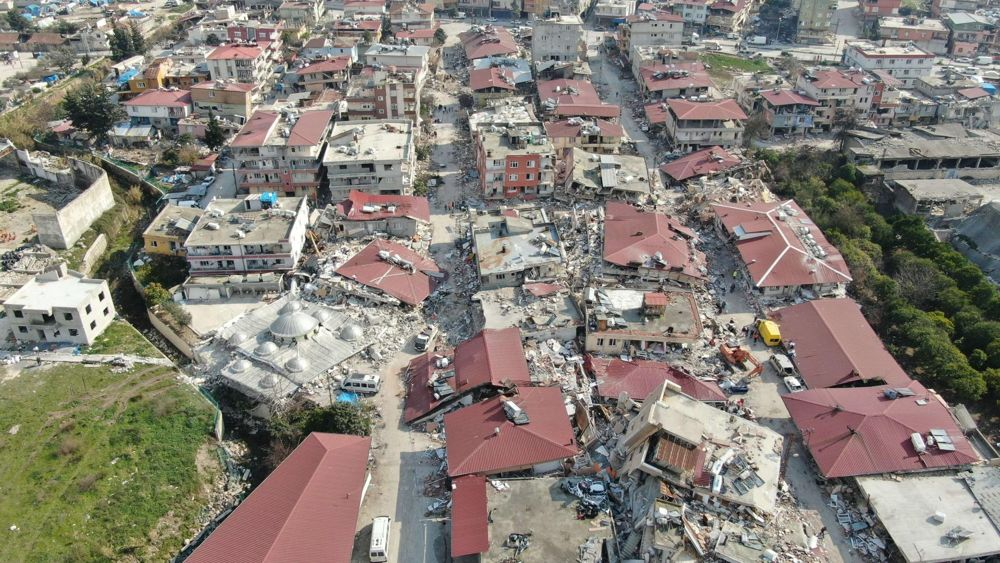

In [ ]:
EARTHQUAKE_IMAGE_B64 = (
    "..."
)

earthquake_image_path = "/content/earthquake_sample.jpg"
with open(earthquake_image_path, "wb") as f:
    f.write(base64.b64decode(EARTHQUAKE_IMAGE_B64))

print(f"Image decoded and saved to: {earthquake_image_path}")
Image.open(earthquake_image_path)

## 3. Known coordinate for this image

Provided directly (not extracted from EXIF, since this copy's metadata was
stripped when it was saved/shared) -- 2023 Turkey earthquake, Hatay/Antakya
region.

In [ ]:
earthquake_lat = 36.198684
earthquake_lon = 36.153847
print(f"Coordinate: {earthquake_lat}, {earthquake_lon}")

Coordinate: 36.198684, 36.153847


## 4. Plot it on a satellite map

One marker, placed exactly at the given coordinate, with the actual photo
embedded in the popup for visual cross-checking against the real map.


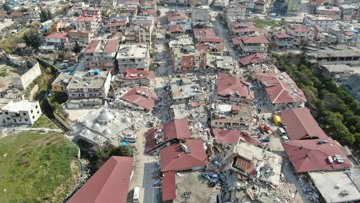

In [ ]:
def image_to_base64_thumbnail(image_path, max_size=(360, 260)):
    img = Image.open(image_path).convert("RGB")
    img.thumbnail(max_size)
    buffer = BytesIO()
    img.save(buffer, format="JPEG", quality=85)
    return base64.b64encode(buffer.getvalue()).decode()


def build_single_image_map(image_path, lat, lon, label="Disaster site", zoom_start=17):
    m = folium.Map(location=[lat, lon], zoom_start=zoom_start, tiles="Esri.WorldImagery")

    thumb_b64 = image_to_base64_thumbnail(image_path)
    popup_html = f"""
    <div style="font-family: sans-serif; font-size: 13px;">
        <img src="data:image/jpeg;base64,{thumb_b64}" width="340"><br>
        <b>{label}</b><br>
        Coords: {lat:.6f}, {lon:.6f}
    </div>
    """
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_html, max_width=380),
        tooltip=f"{label} ({lat:.6f}, {lon:.6f})",
        icon=folium.Icon(color="red", icon="warning-sign", prefix="glyphicon"),
    ).add_to(m)

    return m


earthquake_map = build_single_image_map(
    earthquake_image_path, earthquake_lat, earthquake_lon,
    label="2023 Turkey Earthquake -- Hatay/Antakya"
)
earthquake_map

## Notes

- **Coordinate source**: manually provided alongside the image, not
  extracted from EXIF -- this copy's metadata was stripped when saved/shared,
  which is common for images pulled from news/social sources rather than
  the original camera file. Worth stating plainly in a presentation rather
  than implying it was auto-extracted.
- **No pixel-level registration is attempted here** -- consistent with the
  earlier finding that oblique disaster photography (this image included)
  isn't a good match for homography-based registration; a direct coordinate
  marker is the more reliable approach for this kind of imagery.
- **To add more images**: repeat the pattern in Section 4 -- for each
  new photo, call `build_single_image_map` (or extend it into a
  multi-marker version like the earlier `build_priority_map` /
  `build_coordinate_map` functions) with that image's own path and
  coordinate.


## 5. Additional nearby markers

In [ ]:
import math

def offset_coordinate(lat, lon, distance_m, bearing_deg):
    """Returns a new (lat, lon) offset from the given point by distance_m
    meters in the direction bearing_deg (0 = north, 90 = east, etc.)."""
    R = 6378137.0
    bearing_rad = math.radians(bearing_deg)
    d_lat = (distance_m * math.cos(bearing_rad)) / R
    d_lon = (distance_m * math.sin(bearing_rad)) / (R * math.cos(math.radians(lat)))
    return lat + math.degrees(d_lat), lon + math.degrees(d_lon)


nearby_points = [
    {"label": "Site 2", "coords": offset_coordinate(earthquake_lat, earthquake_lon, 70, 0)},
    {"label": "Site 3", "coords": offset_coordinate(earthquake_lat, earthquake_lon, 60, 90)},
    {"label": "Site 4", "coords": offset_coordinate(earthquake_lat, earthquake_lon, 80, 180)},
    {"label": "Site 5", "coords": offset_coordinate(earthquake_lat, earthquake_lon, 65, 270)},
]

for p in nearby_points:
    print(f"{p['label']}: {p['coords'][0]:.6f}, {p['coords'][1]:.6f}")

Site 2: 36.199313, 36.153847
Site 3: 36.198684, 36.154515
Site 4: 36.197965, 36.153847
Site 5: 36.198684, 36.153123



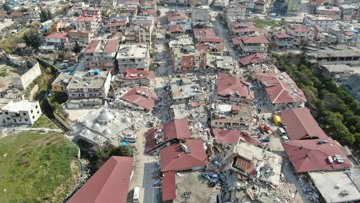

In [ ]:
def build_multi_marker_map(image_path, main_lat, main_lon, main_label,
                            nearby_points, zoom_start=17):
    m = folium.Map(location=[main_lat, main_lon], zoom_start=zoom_start, tiles="Esri.WorldImagery")

    thumb_b64 = image_to_base64_thumbnail(image_path)
    main_popup_html = f"""
    <div style="font-family: sans-serif; font-size: 13px;">
        <img src="data:image/jpeg;base64,{thumb_b64}" width="340"><br>
        <b>{main_label}</b><br>
        Coords: {main_lat:.6f}, {main_lon:.6f}
    </div>
    """
    folium.Marker(
        location=[main_lat, main_lon],
        popup=folium.Popup(main_popup_html, max_width=380),
        tooltip=main_label,
        icon=folium.Icon(color="red", icon="warning-sign", prefix="glyphicon"),
    ).add_to(m)

    for p in nearby_points:
        lat, lon = p["coords"]
        popup_html = f"""
        <div style="font-family: sans-serif; font-size: 13px;">
            <b>{p['label']}</b><br>
            Coords: {lat:.6f}, {lon:.6f}
        </div>
        """
        folium.Marker(
            location=[lat, lon],
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=p["label"],
            icon=folium.Icon(color="orange", icon="flag", prefix="glyphicon"),
        ).add_to(m)

    return m


earthquake_multi_map = build_multi_marker_map(
    earthquake_image_path, earthquake_lat, earthquake_lon,
    "2023 Turkey Earthquake -- Hatay/Antakya", nearby_points
)
earthquake_multi_map